In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Project root: /home/uteam6/computer-vision-equine-grimace-scale
PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: Quadro RTX 4000


In [2]:
from src.datasets.horse_dataset import HorseGrimaceDataset
from src.transforms.image_transforms import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    get_evaluation_transforms,
    get_train_transforms,
)

print("Custom dataset and transforms imported successfully.")

Custom dataset and transforms imported successfully.


In [3]:
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

TRAIN_CSV = SPLITS_DIR / "train.csv"
VALIDATION_CSV = SPLITS_DIR / "validation.csv"
TEST_CSV = SPLITS_DIR / "test.csv"

# Change this if the CSV paths need to be joined with a specific image folder.
IMAGE_ROOT = PROJECT_ROOT

print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VALIDATION_CSV)
print("Test CSV:", TEST_CSV)
print("Image root:", IMAGE_ROOT)

Train CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Test CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/test.csv
Image root: /home/uteam6/computer-vision-equine-grimace-scale


In [4]:
split_paths = {
    "train": TRAIN_CSV,
    "validation": VALIDATION_CSV,
    "test": TEST_CSV,
}

for split_name, split_path in split_paths.items():
    print(
        f"{split_name:12s} | "
        f"exists={split_path.exists()} | "
        f"path={split_path}"
    )

train        | exists=True | path=/home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
validation   | exists=True | path=/home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
test         | exists=True | path=/home/uteam6/computer-vision-equine-grimace-scale/data/splits/test.csv


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train columns:")
print(train_df.columns.tolist())

display(train_df.head())

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train columns:
['image_path', 'split', 'horse_id', 'face_region', 'face_region_code', 'pain_score', 'pain_label', 'binary_pain_label', 'source_filename', 'source_file_id', 'source_sha256', 'exported_sha256', 'perceptual_hash', 'width', 'height', 'mode']


,image_path,split,horse_id,face_region,face_region_code,pain_score,pain_label,binary_pain_label,source_filename,source_file_id,source_sha256,exported_sha256,perceptual_hash,width,height,mode
0,data/raw/train_raw/00000_94683244-ff4_M1_A0__1...,train,M1,ears,A,0,not_present,no_pain,M1_A0 (1).jpg,94683244-ff4d-405f-920b-057e994c2d73,6a70c59eb6104ba3b3dd6b5db3ec5a37a4161a9a064cd9...,66edfe2b41d5ddba718ac96d866bbaee1e732a436d50e0...,f6f6d495c9ccd080,125,260,RGB
1,data/raw/train_raw/00001_41dd5aad-917_M1_A0__1...,train,M1,ears,A,0,not_present,no_pain,M1_A0 (10).jpg,41dd5aad-917c-4ecd-a084-3e569666590a,f1ba7ebfba26a92c69b12938d1e2cb9b1cba10b42e3641...,1a792e35c57dc5a06428d3da469d2d25432bf051c7360b...,be85dfc0e80785f0,196,163,RGB
2,data/raw/train_raw/00002_0c9504eb-c64_M1_A0__1...,train,M1,ears,A,0,not_present,no_pain,M1_A0 (100).jpg,0c9504eb-c647-452b-b101-11f67ddb98d7,4db86c0eac8a8864f1fd77dea7dea58617b510a7743cb5...,396a27b17f3543287ed99a24c0212471ed5c282442bd84...,fdcec0c59891d998,182,165,RGB
3,data/raw/train_raw/00004_d81bac9e-e98_M1_A0__1...,train,M1,ears,A,0,not_present,no_pain,M1_A0 (102).jpg,d81bac9e-e982-4065-9a38-86c404b826a4,bf0fa7bcd45c75857644695da568136c40849046f77eae...,fcf6c9771d69e10181752da5e259ad2d825173dfdd29d4...,aecfc21373718e44,194,237,RGB
4,data/raw/train_raw/00006_f313361a-c03_M1_A0__1...,train,M1,ears,A,0,not_present,no_pain,M1_A0 (104).jpg,f313361a-c035-47e6-ad30-5b758201bded,7d5ff2252abcbdedad6917624a570da27a74da263643d1...,7a23636063edaae8ff03ff8397cb1307368bec0277bb9b...,a7c287f7a96c9809,167,237,RGB



Split sizes:
Train: 2581
Validation: 315
Test: 916


In [7]:
LABEL_COLUMN ="pain_score"
for split_name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print(f"\n{split_name.upper()} LABEL DISTRIBUTION")
    print(
        dataframe[LABEL_COLUMN]
        .value_counts()
        .sort_index()
    )


TRAIN LABEL DISTRIBUTION
pain_score
0    1607
1     555
2     419
Name: count, dtype: int64

VALIDATION LABEL DISTRIBUTION
pain_score
0    203
1     67
2     45
Name: count, dtype: int64

TEST LABEL DISTRIBUTION
pain_score
0    488
1    221
2    207
Name: count, dtype: int64


Create the transformations

In [8]:
IMAGE_SIZE = 224

train_transform = get_train_transforms(
    image_size=IMAGE_SIZE
)

evaluation_transform = get_evaluation_transforms(
    image_size=IMAGE_SIZE
)

print("Training transformations:")
print(train_transform)

print("\nValidation/test transformations:")
print(evaluation_transform)

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.04, 0.04), scale=(0.95, 1.05), shear=[-3.0, 3.0])
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.95, 1.05), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Validation/test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


Create the datasets

In [10]:
train_dataset = HorseGrimaceDataset(
    csv_file=TRAIN_CSV,
    image_root=IMAGE_ROOT,
    transform=train_transform,
    image_column="image_path",
    label_column="pain_score",
    horse_id_column="horse_id",
    face_region_column="face_region",
    verify_images=True,
)

validation_dataset = HorseGrimaceDataset(
    csv_file=VALIDATION_CSV,
    image_root=IMAGE_ROOT,
    transform=evaluation_transform,
    image_column="image_path",
    label_column="pain_score",
    horse_id_column="horse_id",
    face_region_column="face_region",
    verify_images=True,
)

test_dataset = HorseGrimaceDataset(
    csv_file=TEST_CSV,
    image_root=IMAGE_ROOT,
    transform=evaluation_transform,
    image_column="image_path",
    label_column="pain_score",
    horse_id_column="horse_id",
    face_region_column="face_region",
    verify_images=True,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Train samples: 2581
Validation samples: 315
Test samples: 916


In [11]:
sample = train_dataset[0]

print("Returned keys:", sample.keys())
print("Image type:", type(sample["image"]))
print("Image shape:", sample["image"].shape)
print("Label:", sample["label"])
print("Horse ID:", sample["horse_id"])
print("Face region:", sample["face_region"])
print("Image path:", sample["image_path"])

Returned keys: dict_keys(['image', 'label', 'horse_id', 'face_region', 'image_path'])
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Horse ID: M1
Face region: ears
Image path: /home/uteam6/computer-vision-equine-grimace-scale/data/raw/train_raw/00000_94683244-ff4_M1_A0__1_.jpg


Create the DataLoaders

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

print("Batch size:", BATCH_SIZE)
print("Number of workers:", NUM_WORKERS)
print("Pinned memory:", PIN_MEMORY)

Batch size: 32
Number of workers: 2
Pinned memory: True


In [13]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print("DataLoaders created successfully.")

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Training batches: 81
Validation batches: 10
Test batches: 29


In [14]:
train_batch = next(iter(train_loader))
validation_batch = next(iter(validation_loader))
test_batch = next(iter(test_loader))

for split_name, batch in {
    "train": train_batch,
    "validation": validation_batch,
    "test": test_batch,
}.items():
    print(f"\n{split_name.upper()} BATCH")

    print("Images:", batch["image"].shape)
    print("Labels:", batch["label"].shape)
    print("Horse IDs:", len(batch["horse_id"]))
    print("Face regions:", len(batch["face_region"]))
    print("Image paths:", len(batch["image_path"]))


TRAIN BATCH
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Horse IDs: 32
Face regions: 32
Image paths: 32

VALIDATION BATCH
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Horse IDs: 32
Face regions: 32
Image paths: 32

TEST BATCH
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Horse IDs: 32
Face regions: 32
Image paths: 32


In [15]:
def verify_batch(batch, split_name, expected_image_size=224):
    images = batch["image"]
    labels = batch["label"]

    assert images.ndim == 4, (
        f"{split_name}: expected a 4D image batch."
    )

    assert images.shape[1] == 3, (
        f"{split_name}: expected three RGB channels."
    )

    assert images.shape[2] == expected_image_size, (
        f"{split_name}: incorrect image height."
    )

    assert images.shape[3] == expected_image_size, (
        f"{split_name}: incorrect image width."
    )

    assert labels.ndim == 1, (
        f"{split_name}: labels should be a one-dimensional tensor."
    )

    assert set(labels.tolist()).issubset({0, 1, 2}), (
        f"{split_name}: an invalid label was found."
    )

    assert images.dtype == torch.float32, (
        f"{split_name}: images should use torch.float32."
    )

    assert labels.dtype == torch.int64, (
        f"{split_name}: labels should use torch.int64."
    )

    print(f"{split_name}: all batch checks passed.")


verify_batch(train_batch, "Train", IMAGE_SIZE)
verify_batch(validation_batch, "Validation", IMAGE_SIZE)
verify_batch(test_batch, "Test", IMAGE_SIZE)

Train: all batch checks passed.
Validation: all batch checks passed.
Test: all batch checks passed.


class weights

In [16]:
class_counts = (
    train_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

number_of_samples = len(train_df)
number_of_classes = len(class_counts)

class_weights = (
    number_of_samples
    / (number_of_classes * class_counts)
)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32,
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
for class_label, class_weight in zip(
    class_counts.index,
    class_weights_tensor,
):
    print(
        f"Class {class_label}: "
        f"{class_weight.item():.4f}"
    )

print("\nClass-weight tensor:")
print(class_weights_tensor)

Class counts:
pain_score
0    1607
1     555
2     419
Name: count, dtype: int64

Class weights:
Class 0: 0.5354
Class 1: 1.5502
Class 2: 2.0533

Class-weight tensor:
tensor([0.5354, 1.5502, 2.0533])


Check normalization

In [17]:
images = train_batch["image"]

print("Batch minimum:", images.min().item())
print("Batch maximum:", images.max().item())
print("Batch mean:", images.mean().item())
print("Batch standard deviation:", images.std().item())

channel_means = images.mean(dim=(0, 2, 3))
channel_stds = images.std(dim=(0, 2, 3))

print("\nBatch channel means:")
print(channel_means)

print("\nBatch channel standard deviations:")
print(channel_stds)

Batch minimum: -2.1179039478302
Batch maximum: 2.640000104904175
Batch mean: -0.7179000973701477
Batch standard deviation: 0.8097789883613586

Batch channel means:
tensor([-0.8039, -0.7581, -0.5917])

Batch channel standard deviations:
tensor([0.8096, 0.7870, 0.8170])


Visualize one transformed batch

In [18]:
def denormalize_image(image_tensor):
    """
    Reverse ImageNet normalization for visualization.

    Parameters
    ----------
    image_tensor : torch.Tensor
        Tensor with shape [3, H, W].

    Returns
    -------
    torch.Tensor
        Tensor clipped to the range [0, 1].
    """

    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean

    return image.clamp(0, 1)

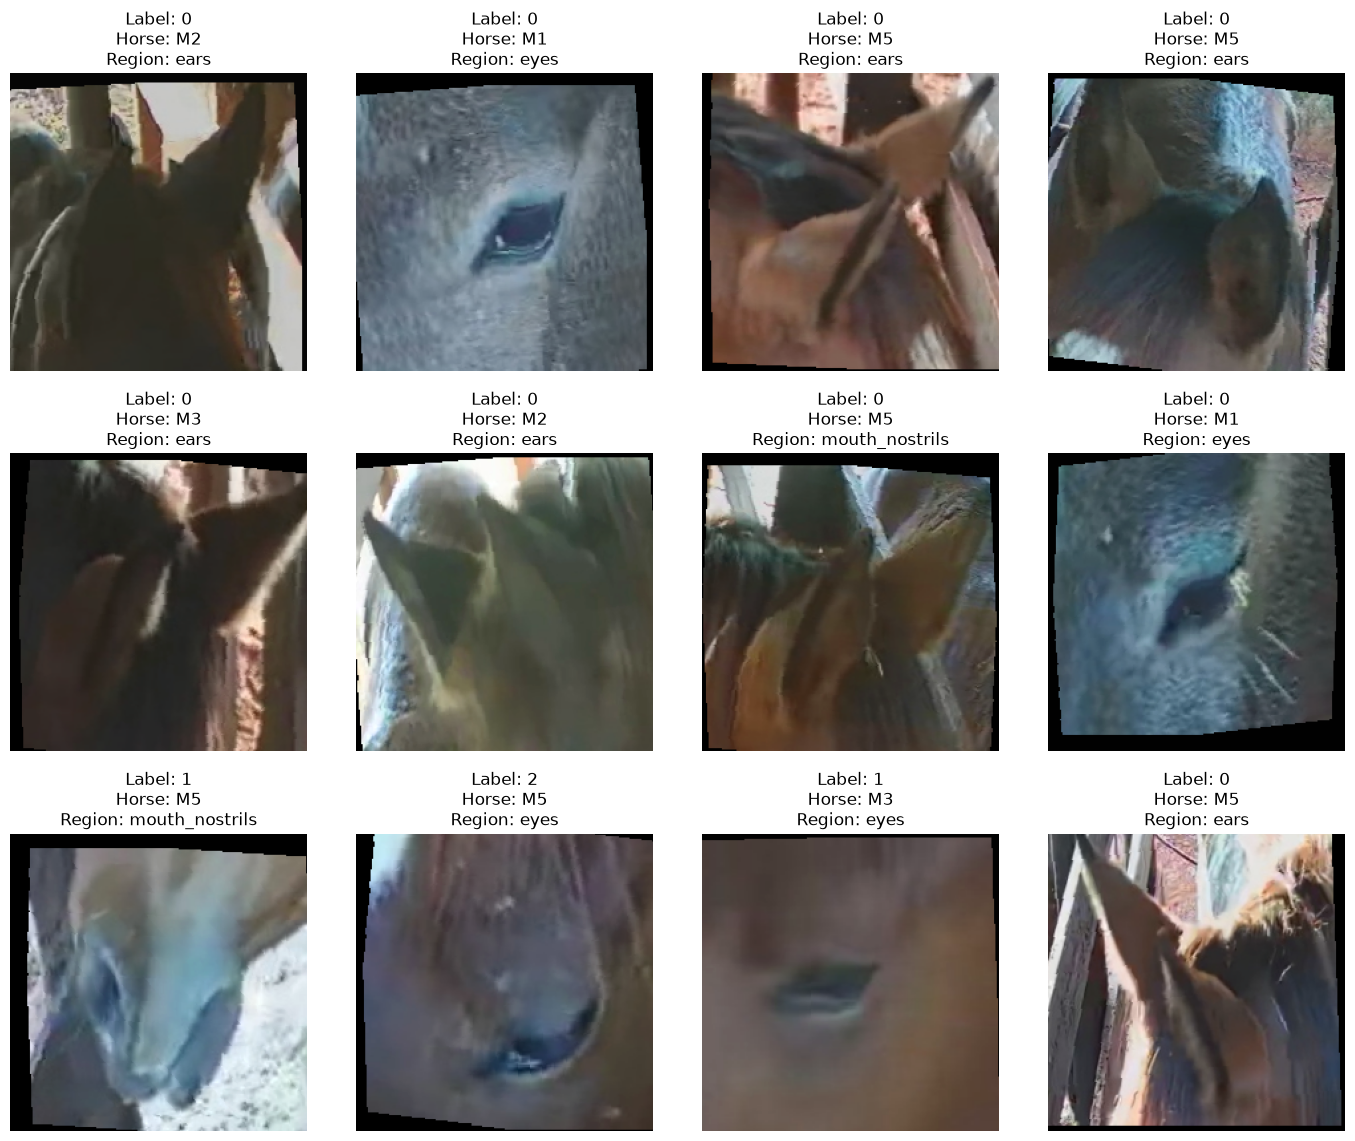

In [23]:
def show_batch(batch, number_of_images=12):
    images = batch["image"]
    labels = batch["label"]
    horse_ids = batch["horse_id"]
    face_regions = batch["face_region"]

    number_of_images = min(
        number_of_images,
        len(images),
    )

    columns = 4
    rows = int(np.ceil(number_of_images / columns))

    plt.figure(figsize=(14, 3.8 * rows))

    for index in range(number_of_images):
        image = denormalize_image(images[index])
        image = image.permute(1, 2, 0).numpy()

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)

        plt.title(
            f"Label: {labels[index].item()}\n"
            f"Horse: {horse_ids[index]}\n"
            f"Region: {face_regions[index]}"
        )

        plt.axis("off")

    plt.tight_layout(h_pad=3.0, w_pad=1.0)
    plt.show()


show_batch(train_batch, number_of_images=12)

Verify validation transformations are deterministic

In [24]:
validation_sample_1 = validation_dataset[0]["image"]
validation_sample_2 = validation_dataset[0]["image"]

validation_difference = torch.abs(
    validation_sample_1 - validation_sample_2
).max()

print(
    "Maximum difference between two validation loads:",
    validation_difference.item(),
)

assert torch.equal(
    validation_sample_1,
    validation_sample_2,
), "Validation transformations are unexpectedly random."

print("Validation transformations are deterministic.")

Maximum difference between two validation loads: 0.0
Validation transformations are deterministic.


Verify training augmentation is active

In [25]:
training_sample_1 = train_dataset[0]["image"]
training_sample_2 = train_dataset[0]["image"]

training_difference = torch.abs(
    training_sample_1 - training_sample_2
).max()

print(
    "Maximum difference between two training loads:",
    training_difference.item(),
)

if torch.equal(training_sample_1, training_sample_2):
    print(
        "The two augmented samples happened to be identical. "
        "Run this cell again because random augmentation may occasionally "
        "apply no visible change."
    )
else:
    print("Training augmentation is active.")

Maximum difference between two training loads: 4.270152568817139
Training augmentation is active.


Test GPU-compatible batch transfer

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

images = train_batch["image"].to(
    device,
    non_blocking=PIN_MEMORY,
)

labels = train_batch["label"].to(
    device,
    non_blocking=PIN_MEMORY,
)

print("Selected device:", device)
print("Images device:", images.device)
print("Labels device:", labels.device)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Selected device: cuda
Images device: cuda:0
Labels device: cuda:0
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


Final Phase 2 summary 

In [27]:
print("=" * 60)
print("PHASE 2 — DATA PIPELINE SUMMARY")
print("=" * 60)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

print(f"\nImage size:         {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Number of workers:  {NUM_WORKERS}")
print(f"Pinned memory:      {PIN_MEMORY}")

print("\nTrain batch shape:     ", train_batch["image"].shape)
print("Validation batch shape:", validation_batch["image"].shape)
print("Test batch shape:      ", test_batch["image"].shape)

print("\nClass counts:")
print(class_counts.to_dict())

print("\nClass weights:")
print(
    {
        int(label): round(float(weight), 4)
        for label, weight in zip(
            class_counts.index,
            class_weights_tensor,
        )
    }
)

print("\nGPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nPhase 2 pipeline checks completed successfully.")

PHASE 2 — DATA PIPELINE SUMMARY
Training samples:   2581
Validation samples: 315
Test samples:       916

Image size:         224 × 224
Batch size:         32
Number of workers:  2
Pinned memory:      True

Train batch shape:      torch.Size([32, 3, 224, 224])
Validation batch shape: torch.Size([32, 3, 224, 224])
Test batch shape:       torch.Size([32, 3, 224, 224])

Class counts:
{0: 1607, 1: 555, 2: 419}

Class weights:
{0: 0.5354, 1: 1.5502, 2: 2.0533}

GPU available: True
GPU: Quadro RTX 4000

Phase 2 pipeline checks completed successfully.
